imports

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from PIL import Image
import numpy as np



show information about dataset

number of total images: 413


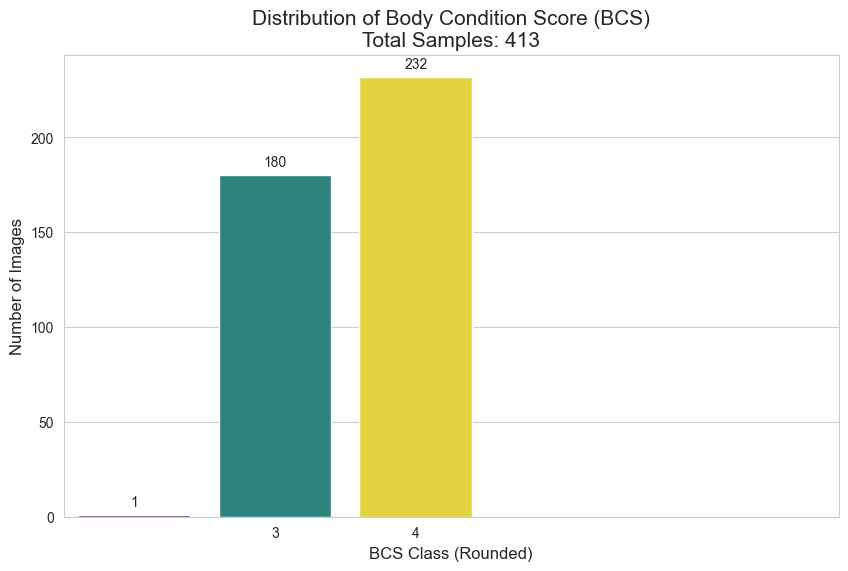

count    413.000000
mean       3.505714
std        0.490215
min        2.500000
25%        3.380000
50%        3.500000
75%        3.750000
max        4.500000
Name: bcs_mean, dtype: float64


In [13]:
df = pd.read_csv("BCS_dataset/labels.csv")
print(f"number of total images: {len(df)}")

if len(df) > 0:
    df["bcs_rounded"] = df["bcs_mean"].round(0).astype(int)  # convert to int numbers to show histogram

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    ax = sns.countplot(x='bcs_rounded', data=df, palette='viridis', hue='bcs_rounded', legend=False)

    plt.title(f'Distribution of Body Condition Score (BCS)\nTotal Samples: {len(df)}', fontsize=15)
    plt.xlabel('BCS Class (Rounded)', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.xticks(range(1, 6))

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points')

    plt.show()

print(df['bcs_mean'].describe())


removing corrupted files

number of corrupted images: 0
number of black images: 0
number of white images: 0
range of width of images: [704]
range of height of images: [576]


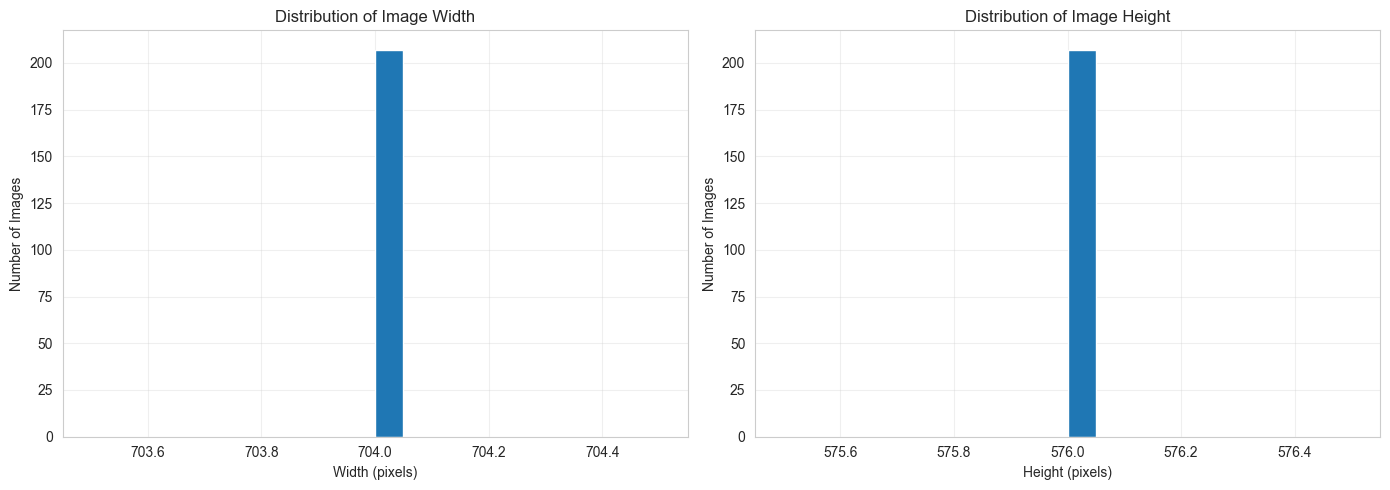

In [16]:
image_dir = "BCS_dataset/images"

corrupted_files = []
black_images = []
white_images = []

widths = []
heights = []

black_threshold = 5
white_threshold = 250

for filename in os.listdir(image_dir):
    path = os.path.join(image_dir, filename)

    if not filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        continue

    try:
        img = Image.open(path)

        width, height = img.size
        widths.append(width)
        heights.append(height)

        img_array = np.array(img)

        mean_pixel = img_array.mean()

        if mean_pixel < black_threshold:
            black_images.append(filename)
        elif mean_pixel > white_threshold:
            white_images.append(filename)

    except:
        corrupted_files.append(filename)

print(f"number of corrupted images: {len(corrupted_files)}")
print(f"number of black images: {len(black_images)}")
print(f"number of white images: {len(white_images)}")

print(f"range of width of images: {list(set(widths))}")
print(f"range of height of images: {list(set(heights))}")

# width distribution

plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plt.hist(widths, bins=20)
plt.title("Distribution of Image Width")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of Images")
plt.grid(alpha=0.3)

# height distribution 
plt.subplot(1, 2, 2)
plt.hist(heights, bins=20)
plt.title("Distribution of Image Height")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of Images")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()





